In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Affichage plus lisible dans le notebook
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Charger les donnees (fichier CSV separe par ;)
file_path = "bank-full.csv"
df = pd.read_csv(file_path, sep=';')

print("Apercu du dataset:")
display(df.head())

print(f"Dimensions: {df.shape[0]} lignes x {df.shape[1]} colonnes")

print("\nTypes des variables:")
display(df.dtypes.to_frame("dtype"))

print("\nValeurs manquantes (nombre et pourcentage):")
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
missing_table = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct
}).sort_values("missing_count", ascending=False)
display(missing_table)

print(f"\nNombre total de valeurs manquantes: {int(missing_count.sum())}")

Apercu du dataset:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


Dimensions: 45211 lignes x 17 colonnes

Types des variables:


,dtype
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64



Valeurs manquantes (nombre et pourcentage):


,missing_count,missing_pct
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
day,0,0.0



Nombre total de valeurs manquantes: 0


Nombre de doublons exacts: 0

Rapport outliers (methode IQR):


,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,pct_outliers
previous,0.0,0.0,0.0,0.0,0.0,8257.0,18.26
pdays,-1.0,-1.0,0.0,-1.0,-1.0,8257.0,18.26
balance,72.0,1428.0,1356.0,-1962.0,3462.0,4729.0,10.46
duration,103.0,319.0,216.0,-221.0,643.0,3235.0,7.16
campaign,1.0,3.0,2.0,-2.0,6.0,3064.0,6.78
age,33.0,48.0,15.0,10.5,70.5,487.0,1.08
day,8.0,21.0,13.0,-11.5,40.5,0.0,0.00


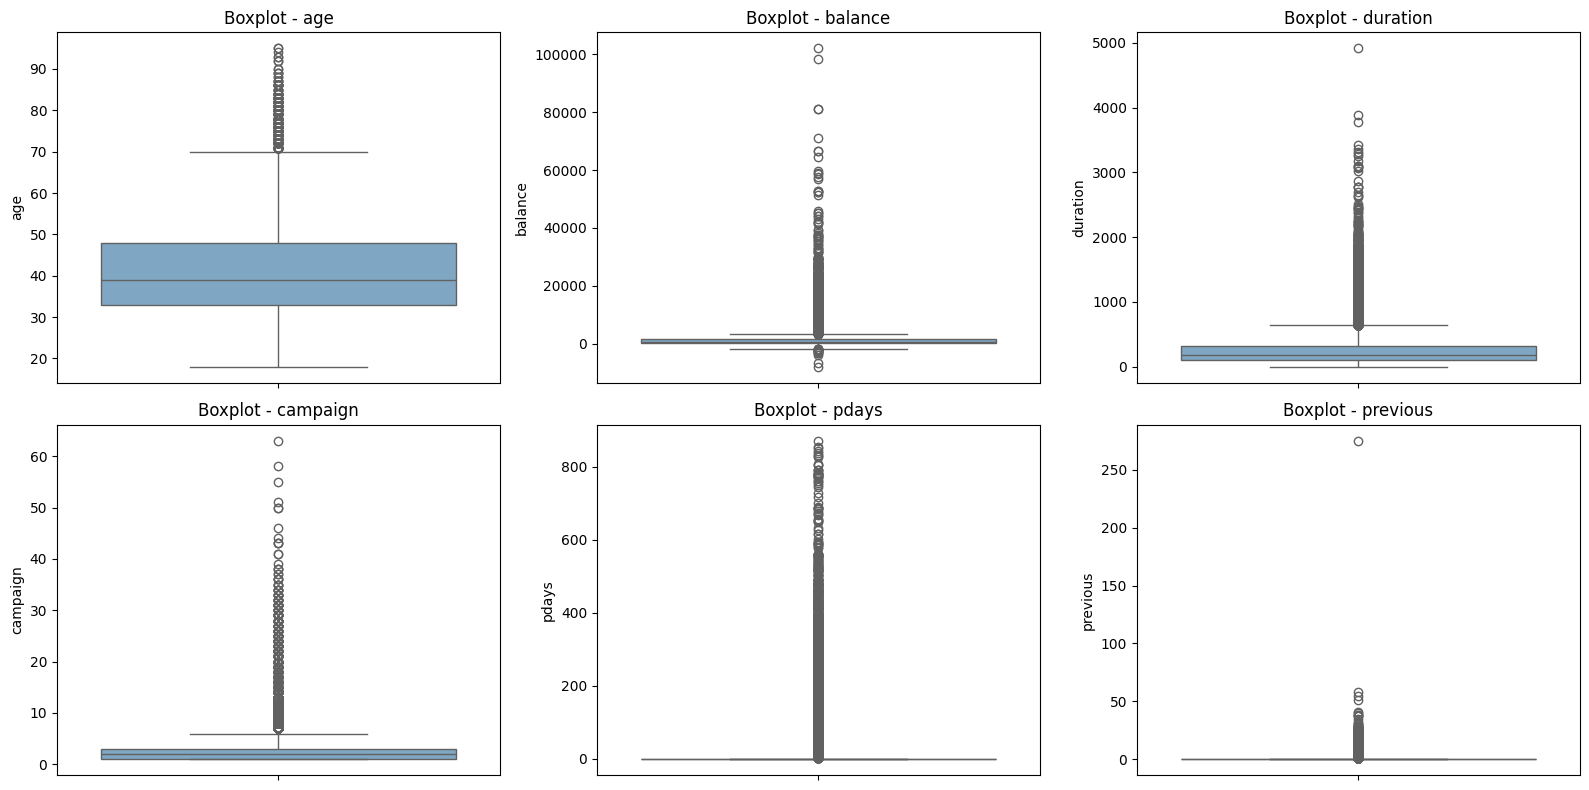

In [2]:
# 1) Doublons
n_duplicates = df.duplicated().sum()
print(f"Nombre de doublons exacts: {n_duplicates}")

# 2) Outliers (IQR) sur variables numeriques
num_cols = df.select_dtypes(include=["number"]).columns.tolist()

def iqr_outlier_count(series: pd.Series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((series < lower) | (series > upper)).sum()
    return pd.Series({
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "n_outliers": int(outliers),
        "pct_outliers": round(outliers / len(series) * 100, 2)
    })

outlier_report = df[num_cols].apply(iqr_outlier_count).T.sort_values("pct_outliers", ascending=False)
print("\nRapport outliers (methode IQR):")
display(outlier_report)

# 3) Boxplots pour visualiser les distributions et valeurs extremes
plot_cols = ["age", "balance", "duration", "campaign", "pdays", "previous"]
plot_cols = [c for c in plot_cols if c in df.columns]

n_cols = 3
n_rows = int(np.ceil(len(plot_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(plot_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="#74a9cf")
    axes[i].set_title(f"Boxplot - {col}")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# 4) Coherence des modalites / regles metier simples
coherence_checks = {
    "age_out_of_range_[18,100]": (~df["age"].between(18, 100)).sum(),
    "duration_negative": (df["duration"] < 0).sum(),
    "campaign_lt_1": (df["campaign"] < 1).sum(),
    "day_out_of_range_[1,31]": (~df["day"].between(1, 31)).sum(),
    "pdays_lt_-1": (df["pdays"] < -1).sum(),
    "previous_negative": (df["previous"] < 0).sum(),
    "target_not_yes_no": (~df["y"].isin(["yes", "no"])).sum()
}


In [6]:
# 1.4 Description des variables (focus projet)

variable_desc = pd.DataFrame([
    ["age", "Numerique", "Age du client (en annees)"],
    ["job", "Categorielle", "Profession du client"],
    ["marital", "Categorielle", "Statut marital"],
    ["education", "Categorielle", "Niveau d'education"],
    ["housing", "Categorielle binaire", "Credit immobilier (yes/no)"],
    ["contact", "Categorielle", "Type de contact (cellular/telephone/unknown)"],
    ["duration", "Numerique", "Duree du dernier appel (en secondes)"],
    ["campaign", "Numerique", "Nombre de contacts durant la campagne en cours"],
    ["poutcome", "Categorielle", "Resultat de la campagne marketing precedente"],
    ["y", "Cible binaire", "Souscription au depot a terme (yes/no)"]
], columns=["variable", "type", "description"])

print("Description des variables demandees:")
display(variable_desc)

# Resume statistique rapide pour interpretation
print("\nResume des variables numeriques:")
display(df[[c for c in ["age", "duration", "campaign"] if c in df.columns]].describe().T)

# Les modelité des variables catégorielle
cat_cols = list(["job", "marital", "education", "housing", "contact", "poutcome", "y"])

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(f"Modalites ({df[col].nunique()}): {sorted(df[col].dropna().unique().tolist())}")

cat_summary = pd.DataFrame({
    "n_modalites": df[cat_cols].nunique(),
    "modalite_plus_frequente": [df[c].mode(dropna=False)[0] for c in cat_cols],
    "freq_modalite_plus_frequente": [df[c].value_counts(dropna=False).iloc[0] for c in cat_cols]
}).sort_values("n_modalites", ascending=False)

print("\nResume des variables categorielles (focus):")
display(cat_summary)

print("\nRepartition de la variable cible y:")
display(df["y"].value_counts(dropna=False).to_frame("count"))
display((df["y"].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("pct"))

Description des variables demandees:


,variable,type,description
0,age,Numerique,Age du client (en annees)
1,job,Categorielle,Profession du client
2,marital,Categorielle,Statut marital
3,education,Categorielle,Niveau d'education
4,housing,Categorielle binaire,Credit immobilier (yes/no)
5,contact,Categorielle,Type de contact (cellular/telephone/unknown)
6,duration,Numerique,Duree du dernier appel (en secondes)
7,campaign,Numerique,Nombre de contacts durant la campagne en cours
8,poutcome,Categorielle,Resultat de la campagne marketing precedente
9,y,Cible binaire,Souscription au depot a terme (yes/no)



Resume des variables numeriques:


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0



--- job ---
Modalites (12): ['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown']

--- marital ---
Modalites (3): ['divorced', 'married', 'single']

--- education ---
Modalites (4): ['primary', 'secondary', 'tertiary', 'unknown']

--- housing ---
Modalites (2): ['no', 'yes']

--- contact ---
Modalites (3): ['cellular', 'telephone', 'unknown']

--- poutcome ---
Modalites (4): ['failure', 'other', 'success', 'unknown']

--- y ---
Modalites (2): ['no', 'yes']

Resume des variables categorielles (focus):


,n_modalites,modalite_plus_frequente,freq_modalite_plus_frequente
job,12,blue-collar,9732
education,4,secondary,23202
poutcome,4,unknown,36959
marital,3,married,27214
contact,3,cellular,29285
housing,2,yes,25130
y,2,no,39922



Repartition de la variable cible y:


,count
y,
no,39922
yes,5289


,pct
y,
no,88.3
yes,11.7


Analyse exploratoire


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_7812\2997410382.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="y", palette="Set2")


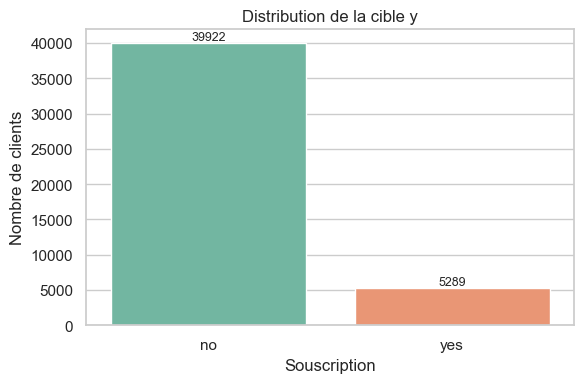

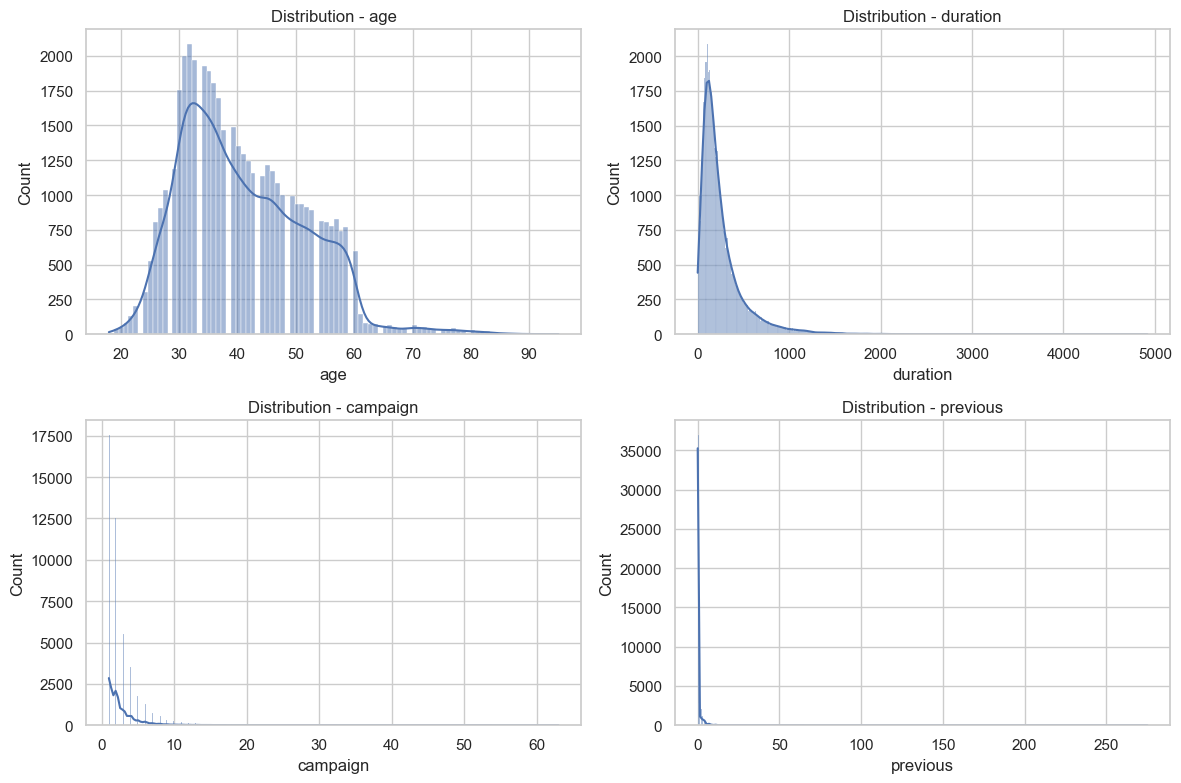

In [7]:
# 2.2 Visualisations principales (strict focus projet)

sns.set_theme(style="whitegrid")

# 1) Repartition de la cible
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="y", palette="Set2")
ax.set_title("Distribution de la cible y")
ax.set_xlabel("Souscription")
ax.set_ylabel("Nombre de clients")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# 2) Histograms des variables numeriques focus
main_num_cols = [c for c in ["age", "duration", "campaign", "previous"] if c in df.columns]
n_cols = 2
n_rows = int(np.ceil(len(main_num_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(main_num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"Distribution - {col}")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


Taux de souscription par job:


,job,n_clients,taux_souscription
8,student,938,28.68
5,retired,2264,22.79
10,unemployed,1303,15.50
4,management,9458,13.76
0,admin.,5171,12.20
6,self-employed,1579,11.84
11,unknown,288,11.81
9,technician,7597,11.06
7,services,4154,8.88
3,housemaid,1240,8.79


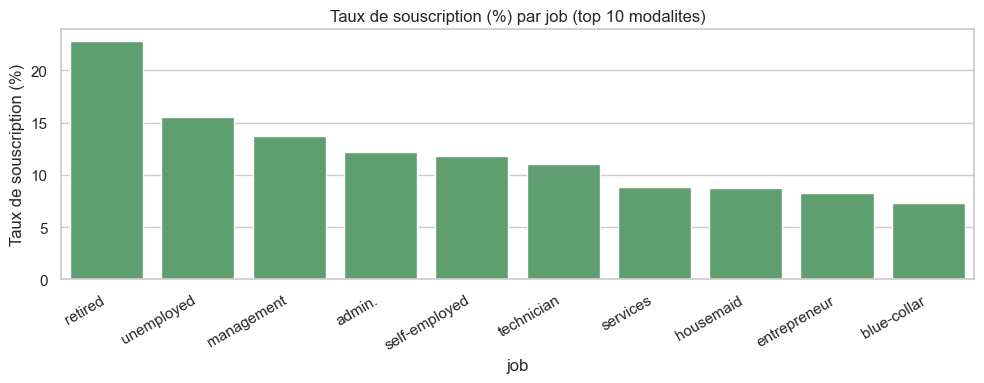


Taux de souscription par marital:


,marital,n_clients,taux_souscription
2,single,12790,14.95
0,divorced,5207,11.95
1,married,27214,10.12


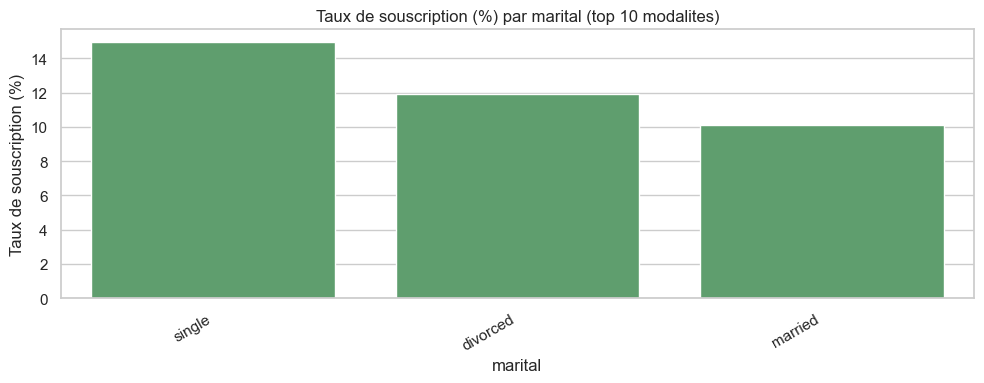


Taux de souscription par education:


,education,n_clients,taux_souscription
2,tertiary,13301,15.01
3,unknown,1857,13.57
1,secondary,23202,10.56
0,primary,6851,8.63


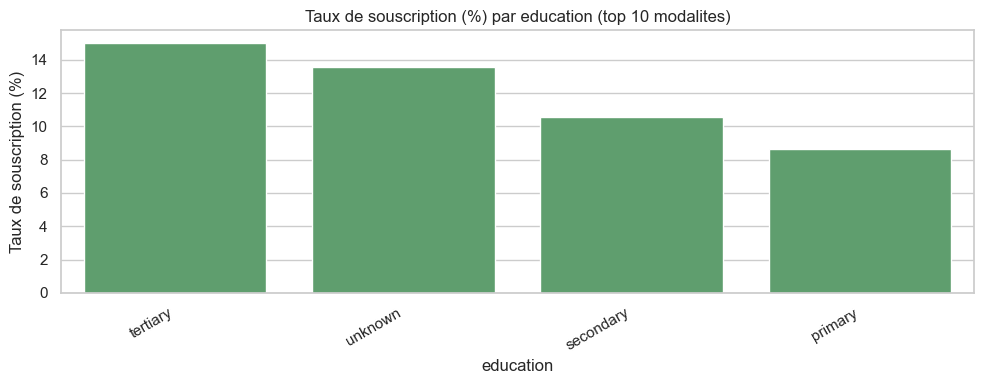


Taux de souscription par housing:


,housing,n_clients,taux_souscription
0,no,20081,16.7
1,yes,25130,7.7


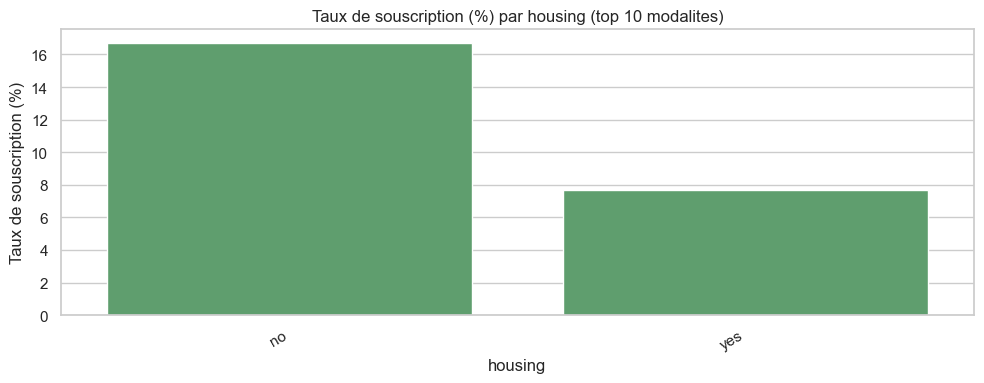


Taux de souscription par contact:


,contact,n_clients,taux_souscription
0,cellular,29285,14.92
1,telephone,2906,13.42
2,unknown,13020,4.07


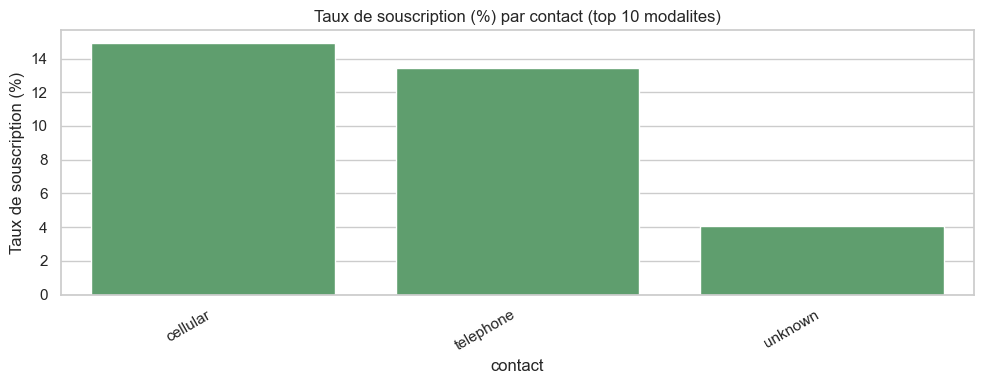


Taux de souscription par poutcome:


,poutcome,n_clients,taux_souscription
2,success,1511,64.73
1,other,1840,16.68
0,failure,4901,12.61
3,unknown,36959,9.16


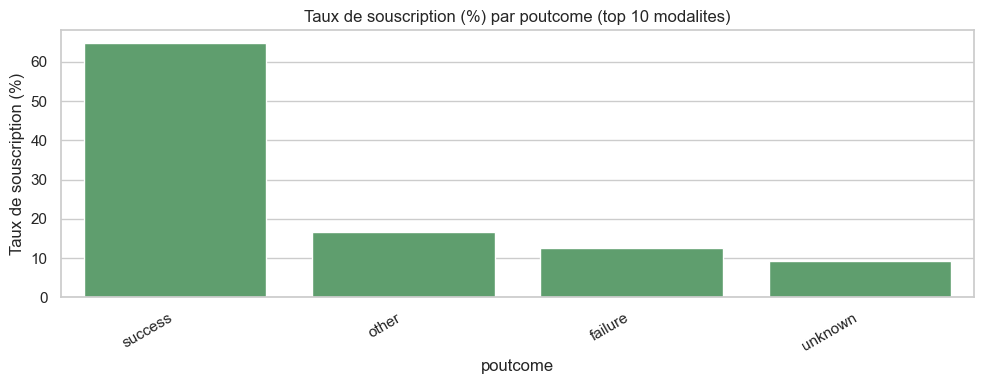


Resume des variables numeriques selon la cible y:


age                              duration                                  campaign                             \
     count   mean median    std min max    count    mean median     std min   max    count  mean median   std min max   
y                                                                                                                       
no   39922  40.84   39.0  10.17  18  95    39922  221.18  164.0  207.38   0  4918    39922  2.85    2.0  3.21   1  63   
yes   5289  41.67   38.0  13.50  18  95     5289  537.29  426.0  392.53   8  3881     5289  2.14    2.0  1.92   1  32   

    previous                              
       count  mean median   std min  max  
y                                         
no     39922  0.50    0.0  2.26   0  275  
yes     5289  1.17    0.0  2.55   0   58


Matrice de correlation (Spearman) - variables numeriques:


,age,duration,campaign,previous
age,1.00,-0.03,0.04,-0.01
duration,-0.03,1.00,-0.11,0.03
campaign,0.04,-0.11,1.00,-0.11
previous,-0.01,0.03,-0.11,1.00


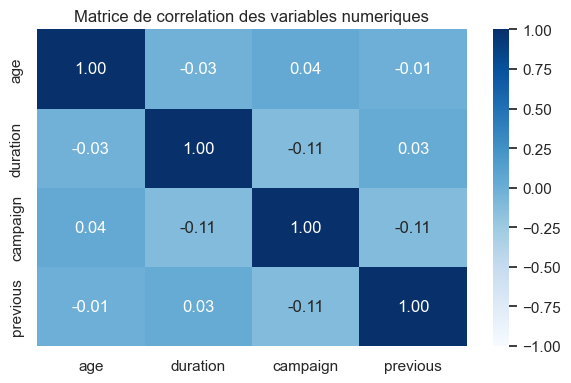

In [10]:
# 2.3 Relations entre variables explicatives et la cible y (strict focus projet)

# Taux de souscription par modalite pour les variables categorielles focus
cat_focus = ["job", "marital", "education", "housing", "contact", "poutcome"]
cat_focus = [c for c in cat_focus if c in df.columns]

df_rate = df.copy()
df_rate["y_bin"] = (df_rate["y"] == "yes").astype(int)

for col in cat_focus:
    tmp = (
        df_rate.groupby(col, as_index=False)
        .agg(n_clients=("y_bin", "size"), taux_souscription=("y_bin", "mean"))
        .sort_values("taux_souscription", ascending=False)
    )
    tmp["taux_souscription"] = (tmp["taux_souscription"] * 100).round(2)
    print(f"\nTaux de souscription par {col}:")
    display(tmp)

    # Graphique des modalites les plus frequentes pour une lecture claire
    top_modalites = df[col].value_counts().head(10).index
    plot_df = tmp[tmp[col].isin(top_modalites)].sort_values("taux_souscription", ascending=False)

    plt.figure(figsize=(10, 4))
    sns.barplot(data=plot_df, x=col, y="taux_souscription", color="#55A868")
    plt.title(f"Taux de souscription (%) par {col} (top 10 modalites)")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Taux de souscription (%)")
    plt.tight_layout()
    plt.show()

# Variables numeriques focus vs cible : resume tabulaire (sans boxplot/densite)
num_focus = [c for c in ["age", "duration", "campaign", "previous"] if c in df.columns]

num_vs_target = (
    df.groupby("y")[num_focus]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

print("\nResume des variables numeriques selon la cible y:")
display(num_vs_target)

# Matrice de correlation des variables numeriques
corr_num = df[num_focus].corr(method="spearman").round(2)
print("\nMatrice de correlation (Spearman) - variables numeriques:")
display(corr_num)

plt.figure(figsize=(6, 4))
sns.heatmap(corr_num, annot=True, cmap="Blues", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matrice de correlation des variables numeriques")
plt.tight_layout()
plt.show()

In [9]:
# 2.4 Tests statistiques (inference) - strict focus projet
from scipy.stats import chi2_contingency, mannwhitneyu

focus_cat_test = [c for c in ["job", "marital", "education", "housing", "contact", "poutcome"] if c in df.columns]
focus_num_test = [c for c in ["age", "duration", "campaign", "previous"] if c in df.columns]

# A) Variables categorielles focus vs y : test du Chi2
chi2_results = []

for col in focus_cat_test:
    contingency = pd.crosstab(df[col], df["y"])
    chi2, p_value, dof, _ = chi2_contingency(contingency)
    chi2_results.append({
        "variable": col,
        "chi2": chi2,
        "dof": dof,
        "p_value": p_value,
        "significatif_5pct": p_value < 0.05
    })

chi2_table = pd.DataFrame(chi2_results).sort_values("p_value")
print("Resultats Chi2 (variables focus categorielles vs y):")
display(chi2_table)



Resultats Chi2 (variables focus categorielles vs y):


,variable,chi2,dof,p_value,significatif_5pct
5,poutcome,4391.506589,3,0.000000e+00,True
4,contact,1035.714225,2,1.251738e-225,True
3,housing,874.822449,1,2.918798e-192,True
0,job,836.105488,11,3.337122e-172,True
2,education,238.923506,3,1.626656e-51,True
1,marital,196.495946,2,2.145100e-43,True


## 3. Modelisation statistique - Regression logistique


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import statsmodels.api as sm

# Variables focus du projet
focus_cat = [c for c in ["job", "marital", "education", "housing", "contact", "poutcome"] if c in df.columns]
focus_num = [c for c in ["age", "duration", "campaign", "previous"] if c in df.columns]

# Recuperer les variables significatives calculees en phase 2 si disponibles
if "chi2_table" in globals() and not chi2_table.empty:
    sig_cat_phase2 = chi2_table.loc[chi2_table["significatif_5pct"], "variable"].tolist()
else:
    sig_cat_phase2 = []

if "num_test_table" in globals() and not num_test_table.empty:
    sig_num_phase2 = num_test_table.loc[num_test_table["significatif_5pct"], "variable"].tolist()
else:
    sig_num_phase2 = []

selected_cat = [c for c in focus_cat if c in sig_cat_phase2] or focus_cat
selected_num = [c for c in focus_num if c in sig_num_phase2] or focus_num

print("Variables categorielles significatives retenues:", selected_cat)
print("Variables numeriques significatives retenues:", selected_num)

# Cible binaire
df_model = df.copy()
df_model["y_bin"] = (df_model["y"] == "yes").astype(int)

def run_logistic_model(data, cat_vars, num_vars, model_name):
    feature_cols = cat_vars + num_vars
    X = data[feature_cols].copy()
    y = data["y_bin"].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    transformers = []
    if num_vars:
        transformers.append(("num", StandardScaler(), num_vars))
    if cat_vars:
        transformers.append(("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_vars))

    preprocessor = ColumnTransformer(transformers=transformers)

    clf = Pipeline(
        steps=[
            ("prep", preprocessor),
            ("logit", LogisticRegression(max_iter=2000, class_weight="balanced")),
        ]
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    perf = {
        "model": model_name,
        "accuracy": round(accuracy_score(y_test, y_pred), 4),
        "precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "f1": round(f1_score(y_test, y_pred, zero_division=0), 4),
        "roc_auc": round(roc_auc_score(y_test, y_proba), 4),
    }

    cm = confusion_matrix(y_test, y_pred)

    # Modele statistique pour interpretation (odds ratios + p-values)
    X_sm = pd.get_dummies(X, columns=cat_vars, drop_first=True)
    X_sm = sm.add_constant(X_sm, has_constant="add").astype(float)

    try:
        sm_model = sm.Logit(y, X_sm).fit(disp=False, maxiter=200)
    except Exception:
        raise

    coef_table = pd.DataFrame({
        "coef": sm_model.params,
        "odds_ratio": np.exp(sm_model.params),
        "p_value": sm_model.pvalues,
    }).sort_values("p_value")

    return perf, cm, coef_table


Variables categorielles significatives retenues: ['job', 'marital', 'education', 'housing', 'contact', 'poutcome']
Variables numeriques significatives retenues: ['age', 'duration', 'campaign', 'previous']


Performances


,model,accuracy,precision,recall,f1,roc_auc
0,Logit,0.827,0.3836,0.7883,0.5161,0.8901


Matrice de confusion


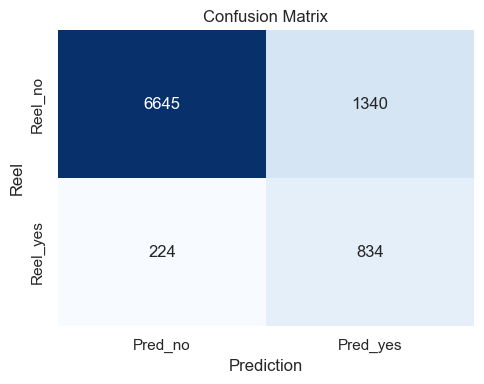

In [14]:
cat_vars_a = selected_cat.copy()
num_vars_a = selected_num.copy()

perf_a, cm_a, coef_a = run_logistic_model(
    data=df_model,
    cat_vars=cat_vars_a,
    num_vars=num_vars_a,
    model_name="Logit"
)

print("Performances")
display(pd.DataFrame([perf_a]))

print("Matrice de confusion")
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_a,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Pred_no", "Pred_yes"],
    yticklabels=["Reel_no", "Reel_yes"]
)
plt.xlabel("Prediction")
plt.ylabel("Reel")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


## 4. Modeles de classification (ML)

Objectifs :
- 4.1 Preprocessing + split train/validation/test + gestion du desequilibre
- 4.2 Entraîner plusieurs modeles
- 4.3 Evaluer avec accuracy, precision, recall, F1, ROC-AUC, matrice de confusion
- 4.4 Comparer les performances et choisir le meilleur modele
- 4.5 Interpretablilite, limites, biais et generalisation

In [15]:
# 4.1 Preprocessing + split + desequilibre

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42
PRIORITY_METRIC = "recall"  # priorite metier : ne pas rater les clients potentiellement souscripteurs
INCLUDE_DURATION = True      # False = scenario operationnel (avant appel)

# Variables selectionnees depuis la phase 2/3
cat_vars_ml = selected_cat.copy() if "selected_cat" in globals() else ["job", "marital", "education", "housing", "contact", "poutcome"]
num_vars_ml = selected_num.copy() if "selected_num" in globals() else ["age", "duration", "campaign", "previous"]

if not INCLUDE_DURATION:
    num_vars_ml = [c for c in num_vars_ml if c != "duration"]

feature_cols_ml = cat_vars_ml + num_vars_ml

# Cible binaire
df_ml = df.copy()
df_ml["y_bin"] = (df_ml["y"] == "yes").astype(int)

X = df_ml[feature_cols_ml]
y = df_ml["y_bin"]

# Split train/validation/test: 70/15/15 (stratifie)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

# Desequilibre de classes
class_counts = y.value_counts().sort_index()
imbalance_table = pd.DataFrame({
    "classe": [0, 1],
    "label": ["no", "yes"],
    "count": [class_counts.get(0, 0), class_counts.get(1, 0)],
    "pct": [round(class_counts.get(0, 0) / len(y) * 100, 2), round(class_counts.get(1, 0) / len(y) * 100, 2)]
})

print("Variables utilisees (ML):", feature_cols_ml)
print("Shapes -> train:", X_train.shape, "valid:", X_valid.shape, "test:", X_test.shape)
print("\nDistribution de la cible (desequilibre):")
display(imbalance_table)

# Preprocessing commun
transformers_ml = []
if num_vars_ml:
    transformers_ml.append(("num", StandardScaler(), num_vars_ml))
if cat_vars_ml:
    transformers_ml.append(("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_vars_ml))

preprocessor_ml = ColumnTransformer(transformers=transformers_ml)

Variables utilisees (ML): ['job', 'marital', 'education', 'housing', 'contact', 'poutcome', 'age', 'duration', 'campaign', 'previous']
Shapes -> train: (36168, 10) valid: (4521, 10) test: (4522, 10)

Distribution de la cible (desequilibre):


,classe,label,count,pct
0,0,no,39922,88.3
1,1,yes,5289,11.7


In [16]:

from xgboost import XGBClassifier
xgb_available = True

# ratio pour scale_pos_weight (classe majoritaire / minoritaire)
pos_count = max(int((y_train == 1).sum()), 1)
neg_count = int((y_train == 0).sum())
scale_pos_weight = neg_count / pos_count

models = {
    "DecisionTree": DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
}

if xgb_available:
    models["XGBoost"] = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="auc",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

fitted_pipelines = {}
rows_valid = []
rows_test = []

for model_name, estimator in models.items():
    pipe = Pipeline(steps=[
        ("prep", preprocessor_ml),
        ("model", estimator)
    ])

    pipe.fit(X_train, y_train)
    fitted_pipelines[model_name] = pipe

    # Validation
    pred_valid = pipe.predict(X_valid)
    proba_valid = pipe.predict_proba(X_valid)[:, 1]

    rows_valid.append({
        "model": model_name,
        "accuracy": accuracy_score(y_valid, pred_valid),
        "precision": precision_score(y_valid, pred_valid, zero_division=0),
        "recall": recall_score(y_valid, pred_valid, zero_division=0),
        "f1": f1_score(y_valid, pred_valid, zero_division=0),
        "roc_auc": roc_auc_score(y_valid, proba_valid),
    })

    # Test
    pred_test = pipe.predict(X_test)
    proba_test = pipe.predict_proba(X_test)[:, 1]

    rows_test.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, pred_test),
        "precision": precision_score(y_test, pred_test, zero_division=0),
        "recall": recall_score(y_test, pred_test, zero_division=0),
        "f1": f1_score(y_test, pred_test, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba_test),
    })

valid_results = pd.DataFrame(rows_valid).sort_values(PRIORITY_METRIC, ascending=False)
test_results = pd.DataFrame(rows_test)

for col in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    valid_results[col] = valid_results[col].round(4)
    test_results[col] = test_results[col].round(4)

print(f"Classement des modeles (validation) selon la metrique prioritaire: {PRIORITY_METRIC}")
display(valid_results)

print("\nPerformances sur jeu de test:")
display(test_results.sort_values(PRIORITY_METRIC, ascending=False))

best_model_name = valid_results.iloc[0]["model"]
best_model = fitted_pipelines[best_model_name]
print(f"\nMeilleur modele retenu (selon {PRIORITY_METRIC} en validation): {best_model_name}")

Classement des modeles (validation) selon la metrique prioritaire: recall


,model,accuracy,precision,recall,f1,roc_auc
2,XGBoost,0.8138,0.3701,0.8431,0.5144,0.9002
0,DecisionTree,0.8576,0.3875,0.3743,0.3808,0.6479
1,RandomForest,0.8914,0.5601,0.3346,0.4189,0.8784



Performances sur jeu de test:


,model,accuracy,precision,recall,f1,roc_auc
2,XGBoost,0.8200,0.3775,0.8299,0.5189,0.8974
0,DecisionTree,0.8594,0.3941,0.3762,0.3849,0.6499
1,RandomForest,0.8978,0.6175,0.3327,0.4324,0.8785



Meilleur modele retenu (selon recall en validation): XGBoost


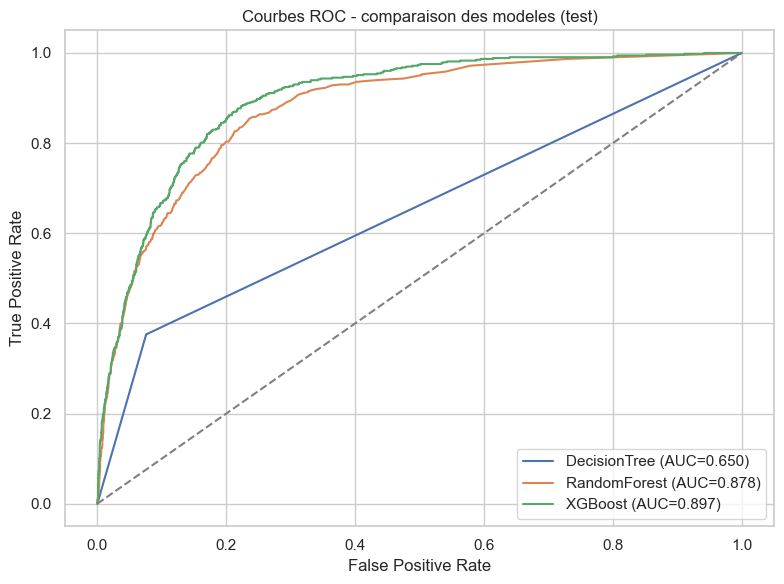

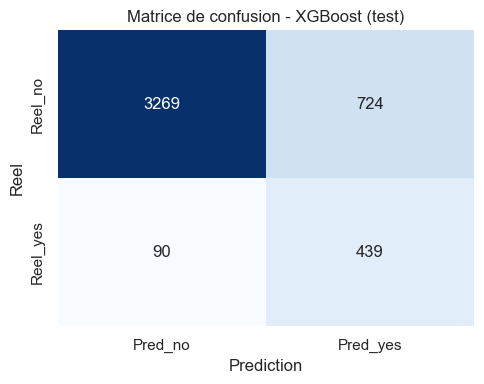

In [17]:
# 4.3 Visualisations: courbes ROC + matrice de confusion du meilleur modele

plt.figure(figsize=(8, 6))
for model_name, pipe in fitted_pipelines.items():
    proba_test = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba_test)
    auc_val = roc_auc_score(y_test, proba_test)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_val:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbes ROC - comparaison des modeles (test)")
plt.legend()
plt.tight_layout()
plt.show()

# Matrice de confusion du meilleur modele
best_pred_test = best_model.predict(X_test)
best_cm = confusion_matrix(y_test, best_pred_test)

plt.figure(figsize=(5, 4))
sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Pred_no", "Pred_yes"],
    yticklabels=["Reel_no", "Reel_yes"]
)
plt.xlabel("Prediction")
plt.ylabel("Reel")
plt.title(f"Matrice de confusion - {best_model_name} (test)")
plt.tight_layout()
plt.show()

In [ ]:
# 4.5 Interpretabilite + limites/biais/generalisation

print("\nDiscussion critique (a reprendre dans le rapport):")
print("- Biais d'echantillonnage potentiel: clients deja contactes, historique incomplet.")
print("- Desequilibre de classes: la classe 'yes' reste minoritaire, d'ou l'importance du recall et F1.")
print("- Generalisation: verifier stabilite avec validation croisee et/ou periode temporelle differente.")
print("- Variable duration: informative mais non disponible avant appel (risque de fuite d'information).")


Discussion critique (a reprendre dans le rapport):
- Biais d'echantillonnage potentiel: clients deja contactes, historique incomplet.
- Desequilibre de classes: la classe 'yes' reste minoritaire, d'ou l'importance du recall et F1.
- Generalisation: verifier stabilite avec validation croisee et/ou periode temporelle differente.
- Variable duration: informative mais non disponible avant appel (risque de fuite d'information).
